Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using files:
gpt: gpt data generated.xlsx
claude: claude_data_generated.xlsx
consensus: consensus data.xlsx


,document_id,source_url,gpt_score,claude_score,consensus_score,weighted_score,max_score,weighted_pct
1,atlassian_2022_april_outage,https://www.atlassian.com/blog/atlassian-engin...,13,13,13,13.00,13,1.000000
5,discord_connectivity_2017,https://discordstatus.com/incidents/dj3l6lw926kl,13,13,13,13.00,13,1.000000
8,gitlab_database_2017,https://about.gitlab.com/blog/postmortem-of-da...,13,13,13,13.00,13,1.000000
12,roblox_2021,https://about.roblox.com/newsroom/2022/01/robl...,13,13,13,13.00,13,1.000000
6,eve_boot_ini_2007,https://www.eveonline.com/news/view/about-the-...,13,12,13,12.75,13,0.980769
4,cloudflare_2019,https://blog.cloudflare.com/details-of-the-clo...,13,11,13,12.50,13,0.961538
3,azure_storage_2014,https://azure.microsoft.com/en-us/blog/update-...,12,11,12,11.75,13,0.903846
2,aws_s3_2008,https://web.archive.org/web/20220403060108/htt...,11,11,10,10.50,13,0.807692
7,github_ddos_2018,https://github.blog/news-insights/company-news...,11,9,10,10.00,13,0.769231
11,mozilla_firefox_2022,https://web.archive.org/web/20250314111052/htt...,11,8,9,9.25,13,0.711538


CSV saved to: /content/drive/MyDrive/phase2_data/weighted_postmortem_scores.csv


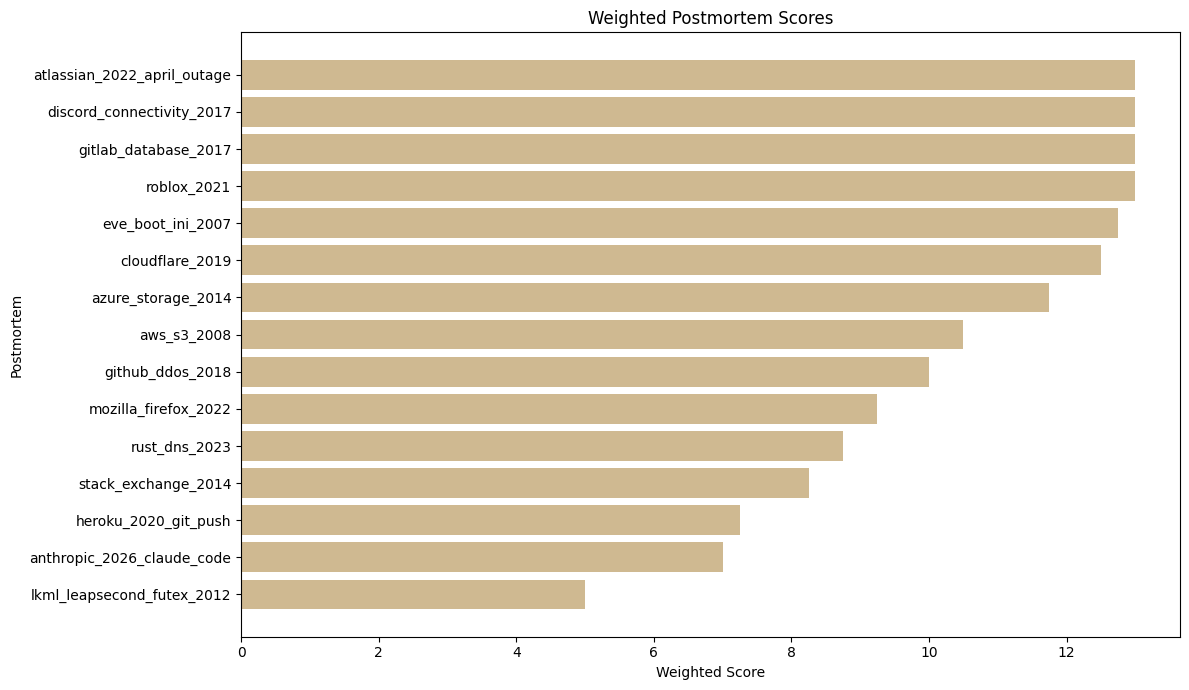

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = "/content/drive/MyDrive/phase2_data"

def find_file(keyword):
    matches = [
        f for f in os.listdir(DATA_DIR)
        if keyword.lower() in f.lower() and f.lower().endswith((".xlsx", ".xls"))
    ]
    if len(matches) == 0:
        raise FileNotFoundError(f"No Excel file found containing '{keyword}' in {DATA_DIR}")
    if len(matches) > 1:
        print(f"Multiple matches for '{keyword}', using: {matches[0]}")
        print("All matches:", matches)
    return matches[0]

FILES = {
    "gpt": find_file("gpt"),
    "claude": find_file("claude"),
    "consensus": find_file("consensus"),
}

WEIGHTS = {
    "gpt": 1.0,
    "claude": 1.0,
    "consensus": 2.0,
}

print("Using files:")
for label, filename in FILES.items():
    print(f"{label}: {filename}")

def load_summary(label, filename):
    path = os.path.join(DATA_DIR, filename)
    df = pd.read_excel(path, sheet_name="Summary")

    df = df[["document_id", "source_url", "total_score", "max_score"]].copy()
    df = df.rename(columns={
        "total_score": f"{label}_score",
        "max_score": f"{label}_max_score",
    })
    return df

dfs = [load_summary(label, filename) for label, filename in FILES.items()]

merged = dfs[0]
for df in dfs[1:]:
    merged = merged.merge(df, on=["document_id", "source_url"], how="outer")

weighted_sum = sum(merged[f"{label}_score"] * WEIGHTS[label] for label in FILES)
weight_total = sum(
    merged[f"{label}_score"].notna().astype(float) * WEIGHTS[label]
    for label in FILES
)

merged["weighted_score"] = weighted_sum / weight_total

max_cols = [f"{label}_max_score" for label in FILES]
merged["max_score"] = merged[max_cols].max(axis=1)
merged["weighted_pct"] = merged["weighted_score"] / merged["max_score"]

result = merged[
    [
        "document_id",
        "source_url",
        "gpt_score",
        "claude_score",
        "consensus_score",
        "weighted_score",
        "max_score",
        "weighted_pct",
    ]
].sort_values("weighted_score", ascending=False)

display(result)

out_csv = os.path.join(DATA_DIR, "weighted_postmortem_scores.csv")
result.to_csv(out_csv, index=False)

print(f"CSV saved to: {out_csv}")

plt.figure(figsize=(12, 7))
plt.barh(result["document_id"], result["weighted_score"], color="#cfb991")
plt.xlabel("Weighted Score")
plt.ylabel("Postmortem")
plt.title("Weighted Postmortem Scores")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()